# Parametric continuous spectrum via an auxiliary network

This notebook isolates the continuous operator (no encoder/decoder). Background
on the encode → Koopman → decode loop is in
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); continuous-time
generators with irregular $\Delta t$ are in
[`12_irregular_sampling_continuous_time.ipynb`](12_irregular_sampling_continuous_time.ipynb).

It demonstrates
`ContinuousKoopmanOperator(..., parameterization="auxiliary_spectral")`: an MLP
maps latent state $z$ to instantaneous eigenvalues and assembles a
**block-diagonal rotation–scaling generator** $L(z)$ (Lusch, Kutz & Brunton,
*Nature Communications* 2018). Lusch et al. parametrize discrete blocks
$K(\mu,\omega)$; here the library uses the continuous-time generator analogue.
On `GraphKoopmanModel`, the matching kwarg is
`koopman_parameterization="auxiliary_spectral"`.

### Caveats (read first)

- This is a **parametric / locally linear** spectrum — **not** a fixed global
  Koopman matrix. State-dependent eigenvalues weaken global spectral-radius
  and Hurwitz certificates.
- Prefer **delay embeddings** (`examples/17_delay_embedding_partial_observability.ipynb`)
  as the first continuous-spectrum tool in practice; this mode is complementary.
- Do **not** overclaim recovery of the continuous spectrum of the
  *infinite-dimensional* Koopman operator.

## Method: what we show

1. Synthetic amplitude-dependent oscillator (frequency rises with radius).
2. Auxiliary mode vs fixed dense generator at matched latent dim.
3. Instantaneous $\hat\omega(z)$ **correlates** with amplitude under advance-only
   MSE (scatter + Pearson / RMSE) — not a tight recovery of $\omega(r)$.


In [1]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn

try:
    from tqdm import TqdmWarning
except ImportError:  # pragma: no cover
    TqdmWarning = UserWarning

warnings.filterwarnings(
    "ignore",
    message=".*IProgress not found.*",
    category=TqdmWarning,
)

from koopman_graph import ContinuousKoopmanOperator

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")
    warnings.filterwarnings("ignore")

# --- notebook globals / hyperparameters ---
SEED = 0
DEVICE = torch.device("cpu")
LATENT_DIM = 2
DELTA_T = 0.1
N_PAIRS = 512
DATA_SEED = 0
EPOCHS = 200
LR = 1e-2
AUX_HIDDEN = (64, 64)
CTRL_HIDDEN = (32,)
CTRL_SEED = 1
HORIZON = 20
HORIZON_STARTS = 32
GAMMA = 0.05
OMEGA_BASE = 1.0
OMEGA_SLOPE = 0.75

_ = torch.manual_seed(SEED)


## Helper functions

Notebook-local helpers used below. They take explicit arguments or only close over
globals defined in the setup cell.


In [2]:
def make_pairs(n_pairs=N_PAIRS, delta_t=DELTA_T, seed=DATA_SEED):
    g = torch.Generator().manual_seed(seed)
    radii = 0.5 + 1.5 * torch.rand(n_pairs, generator=g)
    angles = 2 * torch.pi * torch.rand(n_pairs, generator=g)
    z0 = torch.stack([radii * torch.cos(angles), radii * torch.sin(angles)], dim=-1)
    omega = OMEGA_BASE + OMEGA_SLOPE * radii
    z1 = []
    for i in range(n_pairs):
        w = float(omega[i])
        L = torch.tensor([[-GAMMA, -w], [w, -GAMMA]])
        z1.append(z0[i] @ torch.linalg.matrix_exp(L * delta_t).T)
    return z0, torch.stack(z1), radii, omega


def fit_op(op, z0, z1, *, delta_t=DELTA_T, epochs=EPOCHS, lr=LR):
    opt = torch.optim.Adam(op.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        loss = nn.functional.mse_loss(op.advance(z0, delta_t), z1)
        loss.backward()
        opt.step()
    return float(loss.detach())


def long_horizon_mse(op, starts, *, delta_t=DELTA_T, horizon=HORIZON):
    roll = starts.clone()
    target = starts.clone()
    with torch.no_grad():
        for _ in range(horizon):
            r = target.norm(dim=-1)
            w = OMEGA_BASE + OMEGA_SLOPE * r
            nxt = []
            for i in range(target.shape[0]):
                L = torch.tensor([[-GAMMA, -float(w[i])], [float(w[i]), -GAMMA]])
                nxt.append(target[i] @ torch.linalg.matrix_exp(L * delta_t).T)
            target = torch.stack(nxt)
            roll = op.advance(roll, delta_t)
    return float(nn.functional.mse_loss(roll, target))


## Generate amplitude-dependent oscillator data

Pairs used to fit auxiliary vs dense continuous generators.


In [3]:
z0, z1, radii, true_omega = make_pairs()
z0, z1 = z0.to(DEVICE), z1.to(DEVICE)
print(z0.shape, "delta_t=", DELTA_T)


torch.Size([512, 2]) delta_t= 0.1


## Train

Fit auxiliary-network and dense generators on the same pairs.


In [4]:
torch.manual_seed(SEED)
aux = ContinuousKoopmanOperator(
    LATENT_DIM,
    parameterization="auxiliary_spectral",
    auxiliary_hidden_dims=AUX_HIDDEN,
    init_mode="identity",
).to(DEVICE)
torch.manual_seed(SEED)
dense = ContinuousKoopmanOperator(
    LATENT_DIM, parameterization="dense", init_mode="identity"
).to(DEVICE)

print("aux one-step MSE", fit_op(aux, z0, z1))
print("dense one-step MSE", fit_op(dense, z0, z1))
starts = z0[:HORIZON_STARTS]
aux_h = long_horizon_mse(aux, starts)
dense_h = long_horizon_mse(dense, starts)
print(f"long-horizon MSE  aux={aux_h:.4f}  dense={dense_h:.4f}")
assert aux_h < dense_h, "auxiliary mode should beat fixed dense on this system"


aux one-step MSE 0.0002124695893144235
dense one-step MSE 0.0037545182276517153
long-horizon MSE  aux=0.0369  dense=0.7192


## Evaluate: instantaneous frequency vs amplitude

Advance-only training yields a **positive correlation** between $\hat\omega(z)$
and amplitude. That is weaker than recovering the exact law
$\omega(r)=$ `OMEGA_BASE` $+$ `OMEGA_SLOPE` $\,r$ from the setup cell —
residual bias, a shallower slope, and scatter at fixed $r$ (the MLP sees full
$z$, not $r$ alone) are expected.


Pearson(r, ω̂) = 0.855
ω̂ ≈ 1.523 + 0.405 r  (true: 1.000 + 0.750 r);  RMSE(ω̂, ω) = 0.207
Advance-only MSE encourages useful L(z), not a unique tight ω(r) fit.
sample L(z):
 tensor([[-0.0525, -2.1018],
        [ 2.1018, -0.0525]])
instantaneous eigenvalues: tensor([-0.0525+2.1018j, -0.0525-2.1018j])


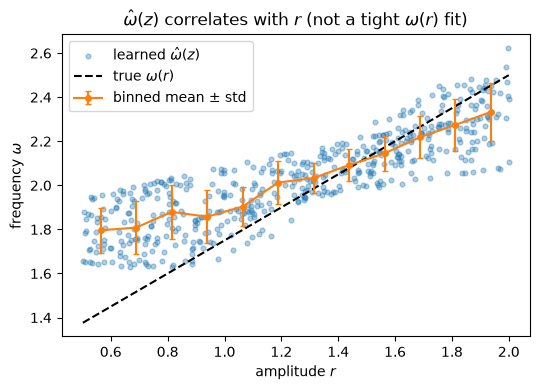

controlled step (untrained API smoke) tensor([0.9974, 0.0349], grad_fn=<AddBackward0>)


In [5]:
with torch.no_grad():
    _mu, omega_hat, _ = aux.auxiliary_net(z0)
    omega_hat = omega_hat.reshape(-1)
    radii_dev = radii.to(DEVICE)
    true_omega_dev = true_omega.to(DEVICE)
    pearson = torch.corrcoef(torch.stack([radii_dev, omega_hat]))[0, 1]
    rmse = torch.sqrt(torch.mean((omega_hat - true_omega_dev) ** 2))
    design = torch.stack([torch.ones_like(radii_dev), radii_dev], dim=1)
    coef, *_ = torch.linalg.lstsq(design, omega_hat)
    intercept, slope = float(coef[0]), float(coef[1])
    L_sample = aux.generator_at(z0[0])
    eig = aux.instantaneous_spectrum(z0[0])

    n_bins = 12
    edges = torch.linspace(float(radii_dev.min()), float(radii_dev.max()), n_bins + 1)
    bin_centers, bin_means, bin_stds = [], [], []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        if i == n_bins - 1:
            mask = (radii_dev >= lo) & (radii_dev <= hi)
        else:
            mask = (radii_dev >= lo) & (radii_dev < hi)
        if not bool(mask.any()):
            continue
        vals = omega_hat[mask]
        bin_centers.append(float(0.5 * (lo + hi)))
        bin_means.append(float(vals.mean()))
        bin_stds.append(float(vals.std(unbiased=False)))

print(f"Pearson(r, ω̂) = {float(pearson):.3f}")
print(
    f"ω̂ ≈ {intercept:.3f} + {slope:.3f} r  "
    f"(true: {OMEGA_BASE:.3f} + {OMEGA_SLOPE:.3f} r);  "
    f"RMSE(ω̂, ω) = {float(rmse):.3f}"
)
print(
    "Advance-only MSE encourages useful L(z), not a unique tight ω(r) fit."
)
print("sample L(z):\n", L_sample)
print("instantaneous eigenvalues:", eig)
assert float(pearson) > 0.7, "expected clear positive amplitude–frequency correlation"
assert slope > 0.0, "learned frequency trend should rise with amplitude"

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(
    radii.numpy(),
    omega_hat.cpu().numpy(),
    s=12,
    alpha=0.35,
    label=r"learned $\hat\omega(z)$",
)
r_line = torch.linspace(float(radii.min()), float(radii.max()), 100)
ax.plot(
    r_line.numpy(),
    (OMEGA_BASE + OMEGA_SLOPE * r_line).numpy(),
    "k--",
    lw=1.5,
    label=r"true $\omega(r)$",
)
ax.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt="o-",
    color="C1",
    ms=4,
    lw=1.5,
    capsize=2,
    label=r"binned mean $\pm$ std",
)
ax.set_xlabel("amplitude $r$")
ax.set_ylabel(r"frequency $\omega$")
ax.set_title(r"$\hat\omega(z)$ correlates with $r$ (not a tight $\omega(r)$ fit)")
ax.legend()
fig.tight_layout()
plt.show()

# API smoke: untrained controlled operator (not the fitted `aux` above).
# Controlled advance freezes L(z) at the step start (locally linear).
torch.manual_seed(CTRL_SEED)
ctrl = ContinuousKoopmanOperator(
    LATENT_DIM,
    parameterization="auxiliary_spectral",
    control_dim=1,
    control_mode="additive",
    auxiliary_hidden_dims=CTRL_HIDDEN,
)
z_c = torch.tensor([1.0, 0.0])
u = torch.tensor([0.1])
z_next = ctrl.advance(z_c, 0.05, control=u)
print("controlled step (untrained API smoke)", z_next)


## Takeaways

- On this oscillator, auxiliary mode beats a matched dense generator on one-step
  and long-horizon MSE.
- `parameterization="auxiliary_spectral"` gives a **state-dependent** continuous
  generator with `generator_at(z)` / `instantaneous_spectrum(z)`.
- Instantaneous $\hat\omega(z)$ correlates with amplitude, but advance-only MSE
  does not force a tight $\omega(r)$ fit — keep spectral claims local.
- Cite Lusch et al. (2018) for the auxiliary-network idea.
- For continuous-spectrum *phenomenology* with partial observations, start with
  delay embeddings (notebook 17), then consider this parameterization when a
  locally linear spectrum is the right inductive bias.

## Next steps

- Pair with `koopman_graph.losses.LieConsistencyLoss` when a known autonomous
  vector field is available (PIKN-style consistency on `generator_at(z)`).
- See [`12_irregular_sampling_continuous_time.ipynb`](12_irregular_sampling_continuous_time.ipynb) for continuous-time irregular sampling.
- See [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) for discrete eigenvalue diagnostics.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
